# ARIMA BEST & Random Forest

## 1. Imports

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from hydrosense.interface.main import load_data



Loading XGBoost...

✅ XGBoost loaded (0.03s)


## 2. Chargement des données
Lecture du fichier CSV contenant les relevés piézométriques du piézomètre Bourdet.

In [4]:
path = '../data/piezo_bourdet_clean.csv'
df = pd.read_csv(path, sep = ';')
df


,date_mesure,niveau_nappe_eau
0,1994-02-01,13.45
1,1994-02-02,13.55
2,1994-02-03,13.79
3,1994-02-04,13.80
4,1994-02-05,13.79
...,...,...
11802,2026-05-26,12.00
11803,2026-05-27,11.96
11804,2026-05-28,11.93
11805,2026-05-29,11.89


### Mise en forme de l'index
Conversion de la colonne `date_mesure` en index temporel de type `DatetimeIndex`.

> **Pourquoi ?** Les méthodes de séries temporelles comme `resample()` nécessitent
> un index de type `DatetimeIndex`. En définissant la date comme index, on peut
> ensuite rééchantillonner, découper et aligner les données par date facilement.



**Pris en charge par function la fonction** `load_data`

In [5]:
df = load_data('../data/piezo_bourdet_clean.csv')
df.head()


⭐️ Use case: load_data
✅ load_data() done — 11807 rows | 1994-02-01 → 2026-05-30



,niveau_nappe_eau
date_mesure,
1994-02-01,13.45
1994-02-02,13.55
1994-02-03,13.79
1994-02-04,13.80
1994-02-05,13.79


### Rééchantillonnage mensuel & découpage Train/Test

Les données brutes sont journalières. On les agrège à la **maille mensuelle** (moyenne) pour :
- Réduire le bruit quotidien
- Aligner avec les modèles hydrologiques saisonniers

Le **folding** isole les **12 derniers mois** (juin 2025 → mai 2026) comme jeu de validation.
Le modèle ne voit jamais ces données pendant l'entraînement — c'est ce qui garantit une évaluation honnête.

In [16]:
from hydrosense.ml_logic.folding import get_folds

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

y_mensuel = df.resample('ME').mean()
print(y_mensuel.head())


# TRAIN / TEST SPLIT
# Split qui termine en mars 2025

from hydrosense.interface.main import split_data


# split_data(y_mensuel) ne marche pas - 2026 pour comparer avec Romain
# puis on fixe 2025

TRAIN_END  = "2026-02-28"
TEST_START = "2026-03-01"
TEST_END   = "2026-05-31"
y_mensuel= y_mensuel.iloc[y_mensuel.index < TRAIN_END]
y_test = y_mensuel.iloc[(y_mensuel.index > TEST_START) & (y_mensuel.index <= TEST_END)]

# ==========================================
# TRAIN / VAL Folding

splits = get_folds(y_mensuel.index, n_splits=10, min_train_years=3 , val_months_duration= 3)
len(splits)

             niveau_nappe_eau
date_mesure                  
1994-02-28          13.602857
1994-03-31          12.908065
1994-04-30          12.849000
1994-05-31          12.503871
1994-06-30          11.899333


9

## 3. Modèle SARIMAX (ARIMA Saisonnier)

**SARIMAX** = Seasonal AutoRegressive Integrated Moving Average with eXogenous variables.

Les paramètres `order=(p, d, q)` contrôlent :
- `p=1` : 1 terme autorégressif (la valeur du mois précédent influence le présent)
- `d=1` : 1 différenciation pour rendre la série stationnaire
- `q=1` : 1 terme de moyenne mobile (correction de l'erreur passée)

Les paramètres `seasonal_order=(P, D, Q, m)` avec `m=12` capturent la **saisonnalité annuelle** :
le niveau de la nappe en juin 2025 est corrélé au niveau de juin 2024, juin 2023, etc.

In [7]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error

In [ ]:
# Un ARIMA(1, 1, 1) avec saisonnalité différenciée (1, 1, 0, 12)
arima_order = (1, 1, 1)
seasonal_order = (1, 1, 0, 12) # Saisonalité mensuelle (12 mois


cv_results = [] # Pour stocker les métriques de chaque fold
all_predictions_df = pd.DataFrame() # Pour stocker toutes les prédictions pour la visualisation


for i,  (train_idx, val_idx) in enumerate(splits):

    print(f"\n--- Fold {i+1}/{len(splits)} ---")

    train_data  = y_mensuel.iloc[train_idx,0]
    val_data = y_mensuel.iloc[val_idx,0]
    model = SARIMAX(train_data, order= arima_order, seasonal_order= seasonal_order )

    try:
        # print(train_data.head())
        print('data shape', train_data.shape)

        arima_fitted = model.fit(disp=False)

        forecast = arima_fitted.predict(start = val_idx[0], end=val_idx[-1])
        forecast = forecast.reindex(val_data.index)

        # TODO comment faire une prediction d'un modele arimax qui n'a pas vu encore le futur
        # est-ce que je peux emmener arima_fitter


        mae_val = mean_absolute_error(val_data, forecast)
        rmse_val = float(np.sqrt(
                    mean_squared_error(val_data, forecast)
                    ))
        me_val  = max_error(val_data, forecast)
        # rajouter des metrics. example :NSE - seasonal eror index


        print(f"{mae_val = :.3f}")
        print(f"{rmse_val = :.3f}")
        print(f"{me_val = :.3f}")

        cv_results.append({
                'fold': i + 1,
                # 'train_start': train_data.index.min(), 'train_end': train_data.index.max(),
                'val_start': val_data.index.min(),
                'val_end': val_data.index.max(),
                'mae_train' : np.nan  ,
                'mse_train': np.nan, 'me_train': np.nan,
                'mae_val': mae_val,
                'rmse_val': rmse_val,
                'me_val' : me_val
            })

        # Stocker les prédictions pour une visualisation ultérieure
        fold_predictions = pd.DataFrame({
                'date': val_data.index,
                'actual': val_data,
                'forecast': forecast,
                'fold': i + 1
            })
        all_predictions_df = pd.concat([all_predictions_df, fold_predictions])


    except Exception as e:
            print(f"  Erreur lors de l'entraînement ou de la prédiction pour le fold {i+1}: {e}")


--- Fold 1/9 ---
data shape (279,)


/home/charourou/.pyenv/versions/Projet_Hydrosense/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


mae_val = 0.260
rmse_val = 0.274
me_val = 0.348

--- Fold 2/9 ---
data shape (289,)
mae_val = 0.198
rmse_val = 0.285
me_val = 0.487

--- Fold 3/9 ---
data shape (301,)
mae_val = 0.383
rmse_val = 0.435
me_val = 0.550

--- Fold 4/9 ---
data shape (315,)
mae_val = 0.442
rmse_val = 0.477
me_val = 0.649

--- Fold 5/9 ---
data shape (326,)
mae_val = 0.101
rmse_val = 0.122
me_val = 0.190

--- Fold 6/9 ---
data shape (337,)
mae_val = 0.186
rmse_val = 0.256
me_val = 0.429

--- Fold 7/9 ---
data shape (349,)
mae_val = 0.638
rmse_val = 0.650
me_val = 0.813

--- Fold 8/9 ---
data shape (361,)
mae_val = 0.152
rmse_val = 0.172
me_val = 0.221

--- Fold 9/9 ---
data shape (375,)
mae_val = 0.361
rmse_val = 0.390
me_val = 0.510


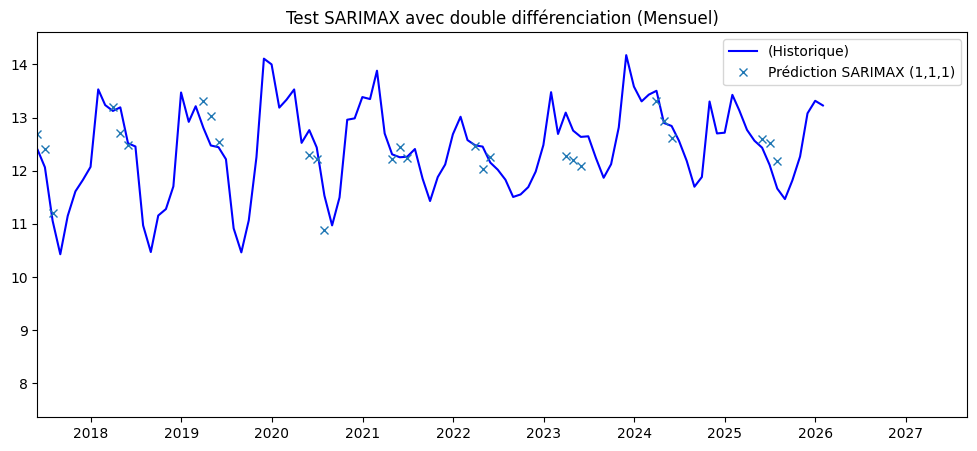

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot()
plt.plot(y_mensuel, label='(Historique)', color='blue')
plt.plot(all_predictions_df['forecast'], 'x',
         label='Prédiction SARIMAX (1,1,1)')

plt.xlim(left = all_predictions_df.index[0])
plt.legend()
plt.title("Test SARIMAX avec double différenciation (Mensuel)")
plt.show()

In [27]:
# all_predictions_df
cv_results

[{'fold': 1,
  'val_start': Timestamp('2017-05-31 00:00:00'),
  'val_end': Timestamp('2017-07-31 00:00:00'),
  'mae_train': nan,
  'mse_train': nan,
  'me_train': nan,
  'mae_val': 0.2599679649933921,
  'rmse_val': 0.2743196878754225,
  'me_val': 0.3482690671153428},
 {'fold': 2,
  'val_start': Timestamp('2018-03-31 00:00:00'),
  'val_end': Timestamp('2018-05-31 00:00:00'),
  'mae_train': nan,
  'mse_train': nan,
  'me_train': nan,
  'mae_val': 0.19839723579467972,
  'rmse_val': 0.28533603025042337,
  'me_val': 0.4874907313347503},
 {'fold': 3,
  'val_start': Timestamp('2019-03-31 00:00:00'),
  'val_end': Timestamp('2019-05-31 00:00:00'),
  'mae_train': nan,
  'mse_train': nan,
  'me_train': nan,
  'mae_val': 0.3834369589013426,
  'rmse_val': 0.4347776705948506,
  'me_val': 0.5502236426907245},
 {'fold': 4,
  'val_start': Timestamp('2020-05-31 00:00:00'),
  'val_end': Timestamp('2020-07-31 00:00:00'),
  'mae_train': nan,
  'mse_train': nan,
  'me_train': nan,
  'mae_val': 0.44187141295

In [28]:
results_df = pd.DataFrame(cv_results)
print("\n--- Résultats détaillés de la Cross-Validation ARIMA ---")
print(results_df)

print("\n--- Métriques moyennes de la Cross-Validation ARIMA ---")
print(f"MAE moyenne: {results_df['mae_val'].mean():.4f} ± {results_df['mae_val'].std():.4f}")
print(f"RMSE moyenne: {results_df['rmse_val'].mean():.4f} ± {results_df['rmse_val'].std():.4f}")


--- Résultats détaillés de la Cross-Validation ARIMA ---
   fold  val_start    val_end  mae_train  mse_train  me_train   mae_val  \
0     1 2017-05-31 2017-07-31        NaN        NaN       NaN  0.259968   
1     2 2018-03-31 2018-05-31        NaN        NaN       NaN  0.198397   
2     3 2019-03-31 2019-05-31        NaN        NaN       NaN  0.383437   
3     4 2020-05-31 2020-07-31        NaN        NaN       NaN  0.441871   
4     5 2021-04-30 2021-06-30        NaN        NaN       NaN  0.101037   
5     6 2022-03-31 2022-05-31        NaN        NaN       NaN  0.185529   
6     7 2023-03-31 2023-05-31        NaN        NaN       NaN  0.637608   
7     8 2024-03-31 2024-05-31        NaN        NaN       NaN  0.152021   
8     9 2025-05-31 2025-07-31        NaN        NaN       NaN  0.361353   

   rmse_val    me_val  
0  0.274320  0.348269  
1  0.285336  0.487491  
2  0.434778  0.550224  
3  0.477113  0.648814  
4  0.121971  0.190280  
5  0.256289  0.428897  
6  0.649624  0.813466  

,date,actual,forecast,fold
date_mesure,,,,
2025-03-31,2025-03-31,12.768387,13.356241,12
2025-04-30,2025-04-30,12.565000,12.873204,12
2025-05-31,2025-05-31,12.432903,12.784649,12


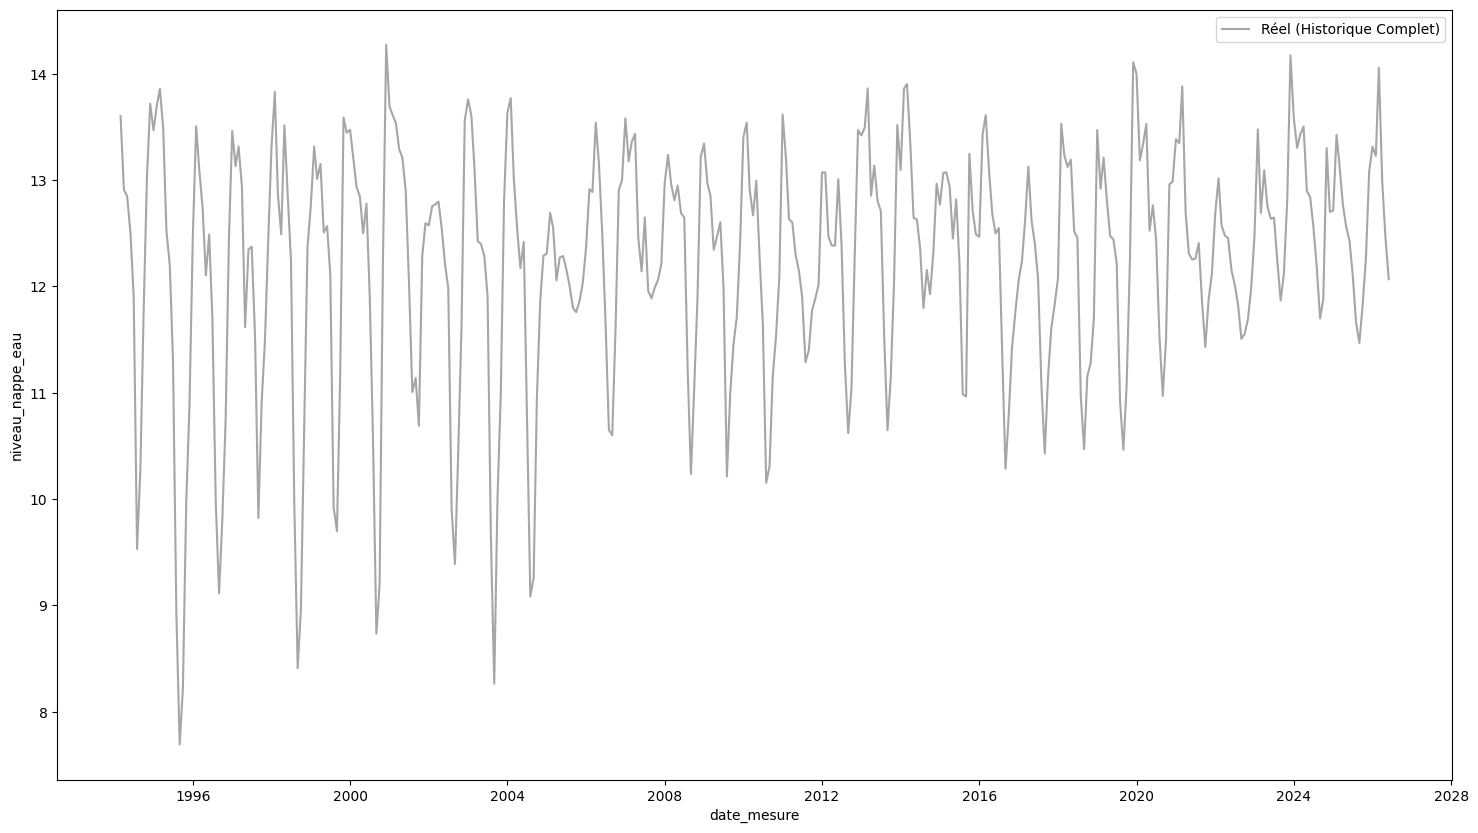

In [35]:
plt.figure(figsize=(18, 10))
sns.lineplot(data=y_mensuel.reset_index(), x='date_mesure', y='niveau_nappe_eau', label='Réel (Historique Complet)', color='gray', alpha=0.7)

for fold_num in all_predictions_df['fold'].unique():
    fold_data = all_predictions_df[all_predictions_df['fold'] == fold_num]

fold_data
#     sns.lineplot(data=fold_data, x='date', y='forecast', label=f'Prévision Fold {fold_num}', linestyle='--', marker='o', markersize=3)
#     # Optionnel: Afficher les données réelles du fold de validation pour comparaison directe
#     # sns.lineplot(data=fold_data, x='date', y='actual', label=f'Réel Fold {fold_num}', color='blue', alpha=0.5)

# plt.title(f"Prévisions ARIMA ({arima_order}, {seasonal_order}) par Fold de Cross-Validation")
# plt.xlabel("Date")
# plt.ylabel("Niveau de la nappe d'eau")
# plt.legend(title='Légende', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

## 4. Random Forest — Feature Engineering

Le **Random Forest** n'est pas un modèle de séries temporelles natif : il ne comprend pas
la notion de temps. On lui fournit donc des **features de lag** (décalages temporels) :

| Feature | Signification |
|---|---|
| `lag_1` | Niveau du mois précédent |
| `lag_2` | Niveau il y a 2 mois |
| `lag_3` | Niveau il y a 3 mois |
| `lag_12` | Niveau il y a 12 mois (même saison l'an dernier) |
| `mois` | Numéro du mois (saisonnalité) |
| `moyenne_3m` | Tendance récente sur 3 mois |
| `moyenne_6m` | Tendance moyen terme sur 6 mois |

On transforme ainsi un problème temporel en problème de **régression supervisée classique**.

### 4.1 Data lagging mensuel + Folding 

In [52]:
# 1. Préparation des colonnes (Lag)
df_ml = pd.DataFrame(y_mensuel)
df_ml['mois'] = df_ml.index.month
df_ml['lag_1'] = df_ml['niveau_nappe_eau'].shift(1)
df_ml['lag_2'] = df_ml['niveau_nappe_eau'].shift(2)
df_ml['lag_3'] = df_ml['niveau_nappe_eau'].shift(3)
df_ml['lag_12'] = df_ml['niveau_nappe_eau'].shift(12)
df_ml = df_ml.dropna()

# 2. Split
X = df_ml[['mois', 'lag_1', 'lag_2', 'lag_3','lag_12']]
y_target = df_ml['niveau_nappe_eau']

#X_train, X_test = X.loc[:'2025-05-31'], X.loc['2025-06-01':]
#y_train, y_test = y_target.loc[:'2025-05-31'], y_target.loc['2025-06-01':]

# X_train, X_test = X.loc[:'2026-02-28'], X.loc['2026-03-01':'2026-05-31']
# y_train, y_test = y_target.loc[:'2026-02-28'], y_target.loc['2026-03-01':'2026-05-31']


# ==========================================
# TRAIN / VAL Folding

splits_ml = get_folds(df_ml.index, n_splits=5, min_train_years=3 , val_months_duration= 3)
len(splits)


9

### 4.2 Fit and predict

In [ ]:
# 3. Fit & Predict
from sklearn.ensemble import RandomForestRegressor

cv_2 = [] # Pour stocker les métriques de chaque fold
all_pred_2 = pd.DataFrame() # Pour stocker toutes les prédictions pour la visualisation

for i, (train_idx, val_idx) in enumerate(splits_ml):

    print(f"\n--- Fold {i+1}/{len(splits_ml)} ---")

    X_train  = X.iloc[train_idx,:]
    y_train = y_target.iloc[train_idx]

    X_val = X.iloc[val_idx,:]
    y_val = y_target.iloc[val_idx]


    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    # options ??


    try:
        rf.fit(X_train, y_train,)
        forecast_rf = pd.Series(rf.predict(X_val), index=y_val.index)


        score_val = rf.score(X_val, y_val)
        score_train = rf.score(X_train, y_train)

        mae_val = mean_absolute_error(y_val, forecast_rf)
        rmse_val = float(np.sqrt(
                    mean_squared_error(y_val, forecast_rf)
                    ))
        me_val  = max_error(val_data, forecast)
        # rajouter des metrics. example :NSE - seasonal eror index

        print(f'r2 train:{score_train:.3f}')
        print(f'r2 val:{score_val:.3f}')

        cv_2.append({
                'fold': i + 1,
                # 'train_start': train_data.index.min(), 'train_end': train_data.index.max(),
                'val_start': y_val.index.min(), 'val_end': y_val.index.max(),
                'r2_train' : score_train  ,
                'r2_val': rmse_val
            })

        # Stocker les prédictions pour une visualisation ultérieure
        fold_predictions = pd.DataFrame({
                'date': y_val.index,
                'actual': y_val,  'forecast': forecast_rf,
                'fold': i + 1
            })
        all_pred_2 = pd.concat([all_pred_2, fold_predictions])

    except Exception as e:
        print(f"  Erreur lors de l'entraînement ou de la prédiction pour le fold {i+1}: {e}")


--- Fold 1/4 ---
data shape (327, 5) (327,)
r2 train:0.960
r2 val:-3.480

--- Fold 2/4 ---
data shape (337, 5) (337,)
r2 train:0.960
r2 val:-2.134

--- Fold 3/4 ---
data shape (349, 5) (349,)
r2 train:0.960
r2 val:0.608

--- Fold 4/4 ---
data shape (363, 5) (363,)
r2 train:0.959
r2 val:0.374


In [54]:
all_pred_2

,date,actual,forecast,fold
date_mesure,,,,
2017-05-31,2017-05-31,12.400323,12.691334,1
2017-06-30,2017-06-30,12.064667,12.412936,1
2017-07-31,2017-07-31,11.059677,11.200301,1
2018-03-31,2018-03-31,13.124839,13.198727,2
2018-04-30,2018-04-30,13.192667,12.705176,2
...,...,...,...,...
2025-06-30,2025-06-30,12.111333,12.201966,9
2025-07-31,2025-07-31,11.664194,12.083556,9
2025-05-31,2025-05-31,12.432903,12.382410,4


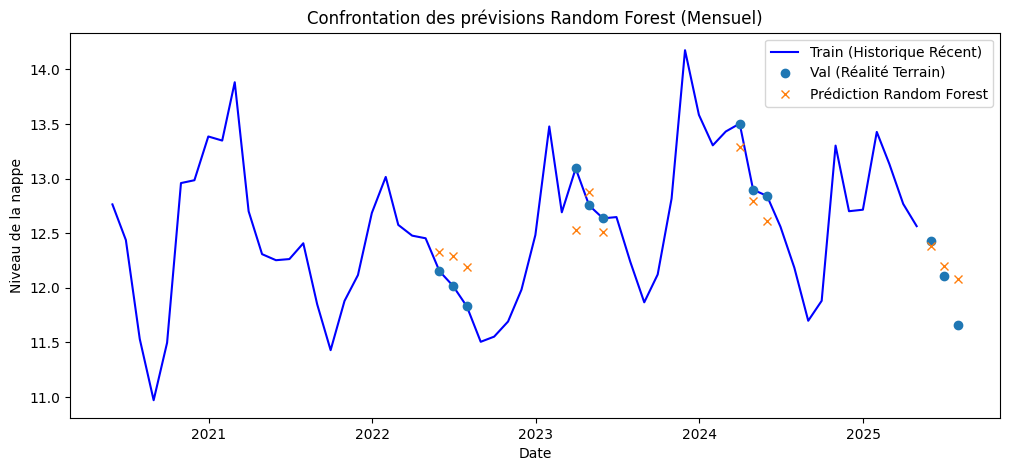

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_train.tail(60), label='Train (Historique Récent)', color='blue')
plt.plot(all_pred_2['actual'], label='Val (Réalité Terrain)', marker='o', linestyle='')
plt.plot(all_pred_2['forecast'], label='Prédiction Random Forest', marker='x',linestyle='')

plt.title("Confrontation des prévisions Random Forest (Mensuel)")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()

### 4.3 grid search pour trouver le meilleur random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. On définit la grille des paramètres que l'on veut tester
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.8, 1.0]
}

# 2. On instancie un Random Forest de base
rf_base = RandomForestRegressor(random_state=42)

# 3. On configure la recherche automatique (GridSearch)
# cv=5 fait une validation croisée pour être sûr de la robustesse
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# 4. On lance la recherche sur les données d'entraînement
grid_search.fit(X_train, y_train)

# 5. On affiche les meilleurs paramètres trouvés !
print("Meilleurs paramètres trouvés :")
print(grid_search.best_params_)

Meilleurs paramètres trouvés :
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}


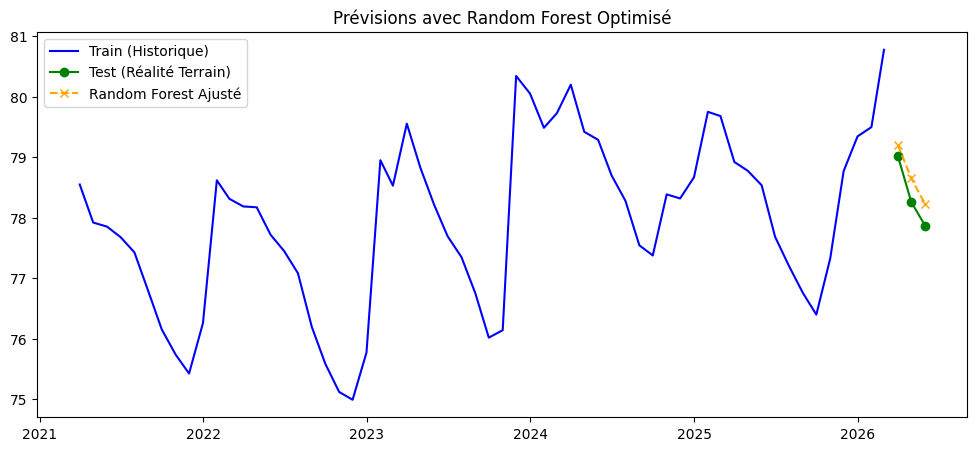

In [ ]:
# 1. On récupère le modèle optimisé
best_rf = grid_search.best_estimator_

# 2. On refait la prédiction
predictions_optimise = best_rf.predict(X_test)
forecast_rf_opt = pd.Series(predictions_optimise, index=y_test.index)

# 3. On l'affiche sur le graphique
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(60), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité Terrain)', color='green', marker='o')
plt.plot(forecast_rf_opt, label='Random Forest Ajusté', color='orange', linestyle='--', marker='x')

plt.title("Prévisions avec Random Forest Optimisé")
plt.legend()

plt.show()

In [ ]:
# Moyenne du niveau de la nappe sur les 3 derniers mois (tendance récente)
df_ml['moyenne_3m'] = df_ml['niveau_nappe_eau'].rolling(window=3).mean()

# Moyenne du niveau sur les 6 derniers mois (tendance moyen terme)
df_ml['moyenne_6m'] = df_ml['niveau_nappe_eau'].rolling(window=6).mean()

# IMPORTANT : Applique le .dropna() APRÈS avoir créé ces nouvelles variables
df_ml = df_ml.dropna()
# Sélection des variables d'entrée (Features)
#X = df_ml[['mois', 'lag_1', 'lag_2', 'lag_3', 'lag_12']]
# Si tu as ajouté les moyennes mobiles, mets :
X = df_ml[['mois', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'moyenne_3m', 'moyenne_6m']]

y_target = df_ml['niveau_nappe_eau']

# Split Train / Test
#X_train, X_test = X.loc[:'2025-05-31'], X.loc['2025-06-01':'2026-05-31']
#y_train, y_test = y_target.loc[:'2025-05-31'], y_target.loc['2025-06-01':'2026-05-31']
X_train, X_test = X.loc[:'2026-02-28'], X.loc['2026-03-01':'2026-05-31']
y_train, y_test = y_target.loc[:'2026-02-28'], y_target.loc['2026-03-01':'2026-05-31']

In [ ]:
X_train

,mois,lag_1,lag_2,lag_3,lag_12,moyenne_3m,moyenne_6m
date_mesure,,,,,,,
2004-01-31,1,78.765806,76.553333,75.542581,79.776452,78.461649,77.186174
2004-02-29,2,80.065806,78.765806,76.553333,79.265714,79.258124,77.615881
2004-03-31,3,78.942759,80.065806,78.765806,78.845790,79.204791,78.079349
2004-04-30,4,78.605806,78.942759,80.065806,78.113183,78.744744,78.603196
2004-05-31,5,78.685667,78.605806,78.942759,78.140968,78.579416,78.918770
...,...,...,...,...,...,...,...
2025-10-31,10,76.400667,76.759032,77.204194,78.388065,76.829254,77.319337
2025-11-30,11,77.328065,76.400667,76.759032,78.320667,77.500910,77.358659
2025-12-31,12,78.774000,77.328065,76.400667,78.671290,78.482946,77.635455


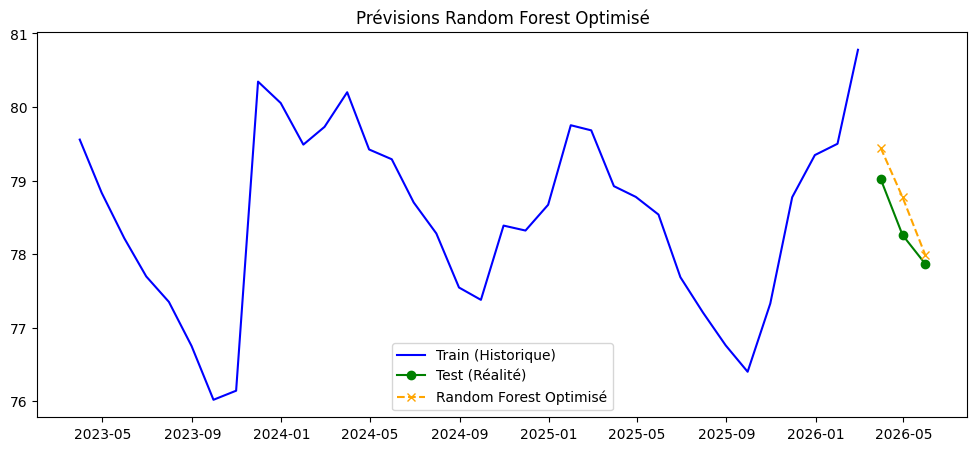

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. Grille de paramètres à tester
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# 2. Lancement de la recherche (ça peut prendre 10-20 secondes)
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 3. Prédiction avec le meilleur modèle trouvé
best_rf = grid_search.best_estimator_
forecast_opt = pd.Series(best_rf.predict(X_test), index=y_test.index)

# 4. Graphique
plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(36), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_opt, label='Random Forest Optimisé', color='orange', linestyle='--', marker='x')
plt.title("Prévisions Random Forest Optimisé")
plt.legend()
plt.show()

In [ ]:
!pip install xgboost

## 5. XGBoost — Gradient Boosting

**XGBoost** est un algorithme de *gradient boosting* : il construit des arbres de décision
en séquence, chaque arbre corrigeant les erreurs du précédent.

Il surpasse souvent le Random Forest sur les séries temporelles car il est plus sensible
aux **relations non-linéaires** et aux **interactions entre features**.

La grille de paramètres testés :
- `n_estimators` : nombre d'arbres
- `learning_rate` : vitesse d'apprentissage (trop élevé = overfitting)
- `max_depth` : profondeur max de chaque arbre
- `subsample` / `colsample_bytree` : régularisation par sous-échantillonnage

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

# 1. On définit la grille des paramètres à tester
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.8, 1.0]
}


# 2. Instanciation du modèle de base
xgb_base = XGBRegressor(random_state=42)

# 3. Configuration de la recherche automatique (avec 3 découpages de validation)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Entraînement sur tes données (X_train et y_train avec les Lags)
grid_search_xgb.fit(X_train, y_train)

# 5. Affichage des meilleurs réglages trouvés
print("Meilleurs paramètres XGBoost :", grid_search_xgb.best_params_)

Meilleurs paramètres XGBoost : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}


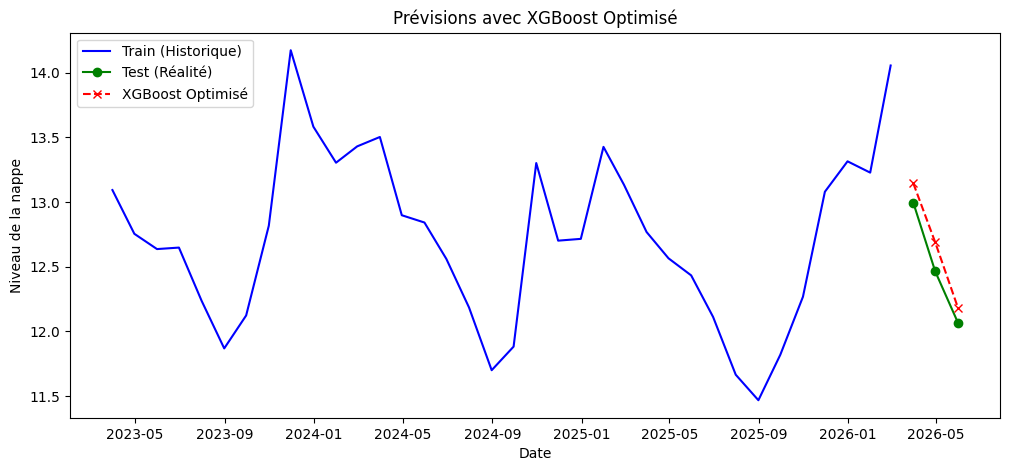

In [ ]:
# 1. Récupération du meilleur modèle
best_xgb = grid_search_xgb.best_estimator_

# 2. Prédiction sur l'année de test
forecast_xgb_opt = pd.Series(best_xgb.predict(X_test), index=y_test.index)

# 3. Graphique de comparaison
plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(36), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_xgb_opt, label='XGBoost Optimisé', color='red', linestyle='--', marker='x')

plt.title("Prévisions avec XGBoost Optimisé")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()

In [ ]:
!pip install prophet

## 6. Prophet — Optimisation des hyperparamètres

**Prophet** (Meta) est conçu pour les séries temporelles avec **saisonnalités fortes et tendances**.
Il décompose la série en : `y(t) = tendance + saisonnalité + bruit`.

Les hyperparamètres clés :
- `changepoint_prior_scale` : flexibilité de la tendance (fort = suit mieux les ruptures)
- `seasonality_prior_scale` : amplitude de la saisonnalité autorisée
- `seasonality_mode` : `additive` (saisons de même amplitude) vs `multiplicative` (saisons proportionnelles)

On effectue un **grid search manuel** sur 3 mois de validation (mars–mai 2026) pour trouver
la combinaison minimisant le RMSE.

In [ ]:
import itertools
from prophet import Prophet
import pandas as pd
import numpy as np

# 1. Formatage des données pour Prophet
df_prophet = y_mensuel.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)

# Split sur les 3 derniers mois (Mars, Avril, Mai 2026)
train_p = df_prophet[df_prophet['ds'] <= '2026-02-28']
test_p = df_prophet[df_prophet['ds'] >= '2026-03-01']

# 2. Définition de la grille de paramètres à tester
param_grid = {
    'changepoint_prior_scale': [0.001, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Générer toutes les combinaisons possibles
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []

# 3. Boucle d'optimisation (Recherche de la plus petite erreur)
for params in all_params:
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, **params)
    m.fit(train_p)

    # Prédire les 3 mois de test
    future = m.make_future_dataframe(periods=3, freq='ME')
    forecast = m.predict(future)
    predictions = forecast['yhat'].iloc[-3:].values

    # Calcul de l'erreur (RMSE) par rapport à la réalité
    rmse = np.sqrt(np.mean((test_p['y'].values - predictions) ** 2))
    rmses.append(rmse)

# Trouver les meilleurs paramètres
best_params = all_params[np.argmin(rmses)]
print("Meilleurs paramètres trouvés pour Prophet :", best_params)

16:19:54 - cmdstanpy - INFO - Chain [1] start processing
16:19:54 - cmdstanpy - INFO - Chain [1] done processing
16:19:54 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:19:54 - cmdstanpy - INFO - Chain [1] start processing
16:19:54 - cmdstanpy - INFO - Chain [1] done processing
16:19:54 - cmdstanpy - INFO - Chain [1] start processing
16:19:54 - cmdstanpy - INFO - Chain [1] done processing
16:19:54 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:19:54 - cmdstanpy - INFO - Chain [1] start processing
16:19:55 - cmdstanpy - INFO - Chain [1] done processing
16:19:55 - cmdstanpy - INFO - Chain [1] start processing
16:19:55 - cmdstanpy - INFO - Chain [1] done processing
16:19:55 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:19:55 - c

Meilleurs paramètres trouvés pour Prophet : {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}


16:20:01 - cmdstanpy - INFO - Chain [1] start processing
16:20:01 - cmdstanpy - INFO - Chain [1] done processing


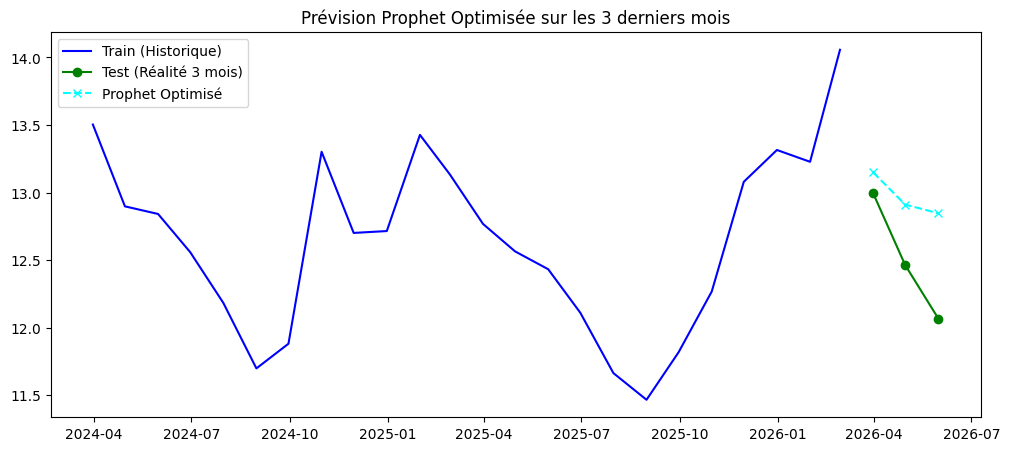

In [ ]:
# 1. Entraînement du meilleur modèle
best_m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, **best_params)
best_m.fit(train_p)

# 2. Prédiction à 3 mois
future = best_m.make_future_dataframe(periods=3, freq='ME')
forecast_final = best_m.predict(future)

# 3. Extraction des 3 points de prédiction
forecast_prophet_opt = pd.Series(forecast_final['yhat'].iloc[-3:].values, index=pd.to_datetime(test_p['ds'].values))

# 4. Graphique zoomé sur la fin pour bien voir les 3 mois
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# On affiche les 2 dernières années pour bien voir l'historique récent
plt.plot(train.tail(24), label='Train (Historique)', color='blue')
plt.plot(test, label='Test (Réalité 3 mois)', color='green', marker='o')
plt.plot(forecast_prophet_opt, label='Prophet Optimisé', color='cyan', linestyle='--', marker='x')

plt.title("Prévision Prophet Optimisée sur les 3 derniers mois")
plt.legend()
plt.show()

In [ ]:
# 'ME' = Month End (anciennement 'M', déprécié depuis pandas 2.2)
y_week = df["niveau_nappe_eau"].resample('W').mean()
y_week

date_mesure
1994-02-06    13.690000
1994-02-13    13.732857
1994-02-20    13.657143
1994-02-27    13.384286
1994-03-06    13.217143
                ...    
2026-05-03    12.151429
2026-05-10    12.118571
2026-05-17    12.105714
2026-05-24    12.064286
2026-05-31    11.946667
Freq: W-SUN, Name: niveau_nappe_eau, Length: 1687, dtype: float64

In [ ]:
# 1. Préparation des colonnes (Lag)
df_w = pd.DataFrame(y_week)
df_w['semaine'] = df_w.index.isocalendar().week
df_w['lag_1'] = df_w['niveau_nappe_eau'].shift(1)
df_w['lag_2'] = df_w['niveau_nappe_eau'].shift(2)
df_w['lag_3'] = df_w['niveau_nappe_eau'].shift(3)
df_w['lag_4'] = df_w['niveau_nappe_eau'].shift(4)
df_w['lag_52'] = df_w['niveau_nappe_eau'].shift(52)


In [ ]:
# Moyenne du niveau de la nappe sur les 3 derniers mois (tendance récente)
df_w['moyenne_3w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=3).mean()

# Moyenne du niveau sur les 6 derniers mois (tendance moyen terme)
df_w['moyenne_6w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=6).mean()

# IMPORTANT : Applique le .dropna() APRÈS avoir créé ces nouvelles variables
df_w = df_w.dropna()

X = df_w[['semaine', 'lag_1', 'lag_2', 'lag_3','lag_4', 'lag_52', 'moyenne_3w', 'moyenne_6w']]

y_target = df_w['niveau_nappe_eau']

# Split Train / Test
X_train, X_test = X.loc[:'2026-02-28'], X.loc['2026-03-01':'2026-05-31']
y_train, y_test = y_target.loc[:'2026-02-28'], y_target.loc['2026-03-01':'2026-05-31']

In [ ]:
X_train.head()

,semaine,lag_1,lag_2,lag_3,lag_4,lag_52,moyenne_3w,moyenne_6w
date_mesure,,,,,,,,
1995-02-05,5,14.321429,13.450000,13.261429,13.645714,13.690000,13.677619,13.619762
1995-02-12,6,13.988571,14.321429,13.450000,13.261429,13.732857,13.920000,13.701429
1995-02-19,7,13.705714,13.988571,14.321429,13.450000,13.657143,14.005238,13.728810
1995-02-26,8,13.908571,13.705714,13.988571,14.321429,13.384286,13.867619,13.772619
1995-03-05,9,13.895714,13.908571,13.705714,13.988571,13.217143,13.836667,13.878333


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

# 1. On définit la grille des paramètres à tester
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.8, 1.0]
}


# 2. Instanciation du modèle de base
xgb_base = XGBRegressor(random_state=42)

# 3. Configuration de la recherche automatique (avec 3 découpages de validation)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Entraînement sur tes données (X_train et y_train avec les Lags)
grid_search_xgb.fit(X_train, y_train)

# 5. Affichage des meilleurs réglages trouvés
print("Meilleurs paramètres XGBoost :", grid_search_xgb.best_params_)


Meilleurs paramètres XGBoost : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}


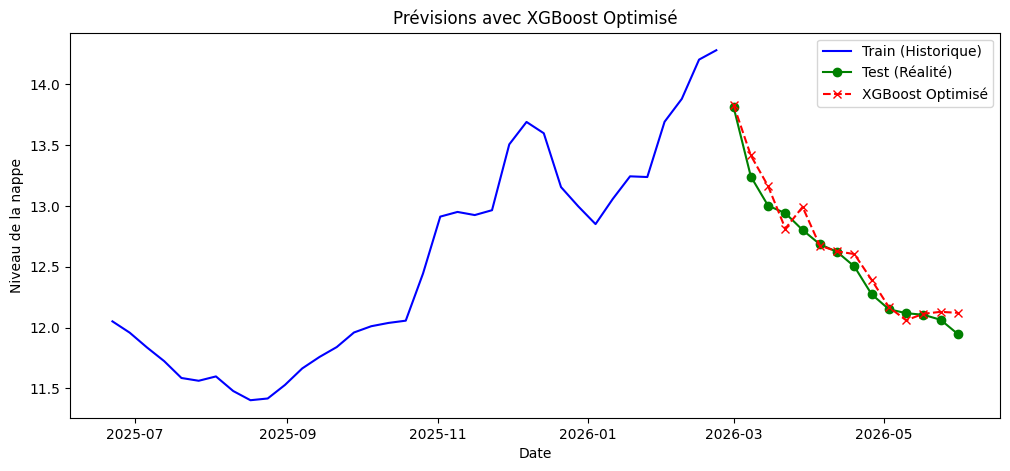

In [ ]:
# 1. Récupération du meilleur modèle
best_xgb = grid_search_xgb.best_estimator_

# 2. Prédiction sur l'année de test
forecast_xgb_opt = pd.Series(best_xgb.predict(X_test), index=y_test.index)

# 3. Graphique de comparaison
plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(36), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_xgb_opt, label='XGBoost Optimisé', color='red', linestyle='--', marker='x')

plt.title("Prévisions avec XGBoost Optimisé")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()